In [1]:
import numpy as np, pandas as pd
import os, time
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             roc_curve, precision_recall_curve, precision_score,
                             recall_score, f1_score, accuracy_score, confusion_matrix)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
PROC = r"D:\Mortgage-Credit-Risk-Analytics\Data\processed"

TRAIN_YEARS = (2004, 2005)   
VAL_YEAR    = 2006           
TEST_YEAR   = 2007           
SCORE_YEARS = list(range(2000, 2011))   


In [2]:
# LEAKAGE-SAFE FEATURE ENGINEERING (fit on TRAIN years only)

og_df = pd.read_parquet(os.path.join(PROC, "master_origination_clean.parquet"))
HPI_PATH = r"D:\Mortgage-Credit-Risk-Analytics\Data\raw\hpi_at_state.xlsx"
hpi = pd.read_excel(HPI_PATH, skiprows=5)[["Abbreviation", "Year", "HPI with 2000 base"]]
hpi.columns = ["state", "year", "hpi"]
hpi["year"] = pd.to_numeric(hpi["year"], errors="coerce")
hpi["hpi"]  = pd.to_numeric(hpi["hpi"], errors="coerce")
hpi = hpi.dropna(subset=["state", "year", "hpi"])
hpi["year"] = hpi["year"].astype(int)

hpi_at = hpi.rename(columns={"year": "origination_year", "hpi": "hpi_at_orig"})
hpi_lag = hpi.copy()
hpi_lag["origination_year"] = hpi_lag["year"] + 3
hpi_lag = hpi_lag.rename(columns={"hpi": "hpi_3yr_before"})[["state", "origination_year", "hpi_3yr_before"]]
macro = hpi_at.merge(hpi_lag, on=["state", "origination_year"], how="left")
macro["hpi_change_3yr_prior"] = (macro["hpi_at_orig"] / macro["hpi_3yr_before"] - 1) * 100
macro = macro[["state", "origination_year", "hpi_at_orig", "hpi_change_3yr_prior"]]

og_df = og_df.merge(macro, left_on=["prop_state", "origination_year"],
                    right_on=["state", "origination_year"], how="left").drop(columns="state")

print(f"og_df shape after HPI merge: {og_df.shape}")
print(f"macro coverage: {(1 - og_df['hpi_change_3yr_prior'].isna().mean())*100:.2f}%")

IMPUTE = ["cred_score", "og_ltv", "og_dti", "mortgage_insurance_percent",
          "unit_no", "no_of_borrowers", "hpi_at_orig", "hpi_change_3yr_prior"]
CAT_COLS = ["loan_purpose", "occupancy_status", "prop_type", "first_time_homebuyer_flag",
            "channel", "prop_state"]
NUM_CANDS = ["cred_score", "og_ltv", "og_dti", "og_int_rate", "og_upb", "og_loan_term",
             "mortgage_insurance_percent", "hpi_at_orig", "hpi_change_3yr_prior"]
CAT_CANDS = ["loan_purpose", "occupancy_status", "prop_type",
             "first_time_homebuyer_flag", "channel", "prop_state"]
IV_THRESHOLD = 0.02

def split_by_years(df, y0, y1):
    return df[df["origination_year"].between(y0, y1)].copy()

def _fit_woe_col(train, feature, is_numeric, bins=10):
    x = train[[feature, "is_default"]].copy()
    if is_numeric:
        edges = np.quantile(x[feature].dropna(), np.linspace(0, 1, bins + 1))
        edges = np.unique(edges); edges[0], edges[-1] = -np.inf, np.inf
        x["bin"] = pd.cut(x[feature], edges); kind = "num"
    else:
        edges = None; x["bin"] = x[feature].astype(str); kind = "cat"
    g = x.groupby("bin", observed=True)["is_default"].agg(["count", "sum"])
    g["good"] = (g["count"] - g["sum"]) + 0.5
    g["bad"]  = g["sum"] + 0.5
    g["woe"]  = np.log((g["good"] / g["good"].sum()) / (g["bad"] / g["bad"].sum()))
    iv = (((g["good"] / g["good"].sum()) - (g["bad"] / g["bad"].sum())) * g["woe"]).sum()
    tot = g["good"].sum() + g["bad"].sum()
    gwoe = np.log((g["good"].sum() / tot) / (g["bad"].sum() / tot))
    return {str(k): v for k, v in g["woe"].items()}, gwoe, edges, kind, iv

def fit_fe(train):
    A, train = {}, train.copy()
    A["medians"] = train[IMPUTE].median()
    train[IMPUTE] = train[IMPUTE].fillna(A["medians"])
    for c in CAT_COLS:
        train[c] = train[c].astype(str).replace("nan", "Missing").fillna("Missing")

    woe_maps, iv_rows = {}, []
    for f in NUM_CANDS:
        wm, gw, ed, kd, iv = _fit_woe_col(train, f, True); woe_maps[f] = (wm, gw, ed, kd); iv_rows.append((f, iv))
    for f in CAT_CANDS:
        wm, gw, ed, kd, iv = _fit_woe_col(train, f, False); woe_maps[f] = (wm, gw, ed, kd); iv_rows.append((f, iv))
    iv_df = pd.DataFrame(iv_rows, columns=["feature", "IV"]).sort_values("IV", ascending=False)
    A["selected"] = list(iv_df.loc[iv_df["IV"] >= IV_THRESHOLD, "feature"])
    A["woe_maps"], A["iv_df"] = woe_maps, iv_df

    A["ohe_cats"] = {c: sorted(train[c].dropna().unique()) for c in CAT_CANDS}
    A["scaler"] = StandardScaler().fit(train[NUM_CANDS])
    return A

def apply_fe(df, A):
    df = df.copy()
    df[IMPUTE] = df[IMPUTE].fillna(A["medians"])
    for c in CAT_COLS:
        df[c] = df[c].astype(str).replace("nan", "Missing").fillna("Missing")

    woe = pd.DataFrame(index=df.index)
    for f in A["selected"]:
        wm, gw, ed, kd = A["woe_maps"][f]
        key = pd.cut(df[f], ed).astype(str) if kd == "num" else df[f].astype(str)
        woe[f + "_woe"] = key.map(wm).astype(float).fillna(gw)
    woe["is_default"] = df["is_default"].values

    raw = pd.DataFrame(index=df.index)
    raw[NUM_CANDS] = A["scaler"].transform(df[NUM_CANDS])
    for c in CAT_CANDS:
        for cat in A["ohe_cats"][c]:
            raw[f"{c}_{cat}"] = (df[c].astype(str) == str(cat)).astype(int)
    raw["is_default"] = df["is_default"].values
    return woe, raw

og_df shape after HPI merge: (550000, 35)
macro coverage: 99.69%


In [3]:
# TRAIN (2004-05) / VAL (2006) / TEST (2007)

tr_df = split_by_years(og_df, *TRAIN_YEARS)
va_df = split_by_years(og_df, VAL_YEAR, VAL_YEAR)
te_df = split_by_years(og_df, TEST_YEAR, TEST_YEAR)

A = fit_fe(tr_df)
woe_tr, raw_tr = apply_fe(tr_df, A)
woe_va, raw_va = apply_fe(va_df, A)
woe_te, raw_te = apply_fe(te_df, A)

TARGET = "is_default"
def xy(df): return df.drop(columns=TARGET), df[TARGET]

Xw_tr, yw_tr = xy(woe_tr); Xw_va, yw_va = xy(woe_va); Xw_te, yw_te = xy(woe_te)
Xr_tr, yr_tr = xy(raw_tr); Xr_va, yr_va = xy(raw_va); Xr_te, yr_te = xy(raw_te)

print(f"train {TRAIN_YEARS} : {Xw_tr.shape[0]:>7,} rows, default {yw_tr.mean()*100:.2f}%")
print(f"val   {VAL_YEAR}    : {Xw_va.shape[0]:>7,} rows, default {yw_va.mean()*100:.2f}%")
print(f"test  {TEST_YEAR}    : {Xw_te.shape[0]:>7,} rows, default {yw_te.mean()*100:.2f}%")
print(f"\nWoE features selected (IV >= {IV_THRESHOLD}): {len(A['selected'])}")
print(A["iv_df"].head(8).to_string(index=False))


train (2004, 2005) : 100,000 rows, default 9.07%
val   2006    :  50,000 rows, default 14.43%
test  2007    :  50,000 rows, default 16.53%

WoE features selected (IV >= 0.02): 10
             feature       IV
          cred_score 0.603494
              og_ltv 0.235910
         og_int_rate 0.191595
          prop_state 0.156556
        og_loan_term 0.148935
              og_dti 0.110843
hpi_change_3yr_prior 0.095037
         hpi_at_orig 0.090924


In [4]:
# EVALUATION ENGINE 
def ks_stat(y, p):
    fpr, tpr, _ = roc_curve(y, p)
    return float(np.max(tpr - fpr))

def ranking_metrics(y, p):
    auc = roc_auc_score(y, p)
    return {"AUC": auc, "Gini": 2*auc - 1, "KS": ks_stat(y, p),
            "PR_AUC": average_precision_score(y, p), "Brier": brier_score_loss(y, p)}

def class_metrics(y, p, thr):
    y = np.asarray(y); yhat = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yhat, labels=[0, 1]).ravel()
    return {"thr": float(thr),
            "Precision": precision_score(y, yhat, zero_division=0),
            "Recall": recall_score(y, yhat, zero_division=0),
            "F1": f1_score(y, yhat, zero_division=0),
            "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
            "Accuracy": accuracy_score(y, yhat)}

def evaluate(y, p, thr):
    return {**ranking_metrics(y, p), **class_metrics(y, p, thr)}

def pick_threshold(y, p, method="f1", grid=None):
    if grid is None:
        grid = np.round(np.arange(0.01, 0.601, 0.005), 4)
    y = np.asarray(y)
    rows = [{"thr": t, **class_metrics(y, p, t)} for t in grid]
    sw = pd.DataFrame(rows)
    sw["Youden"] = sw["Recall"] + sw["Specificity"] - 1
    best = sw.loc[sw["F1"].idxmax()] if method == "f1" else sw.loc[sw["Youden"].idxmax()]
    return float(best["thr"]), sw


In [5]:
# BASELINE LEADERBOARD: LogReg (WOE) / RandomForest (raw) / XGBoost (raw)
# threshold frozen on validation (2006, F1 rule), scored once on test (2007)

models = {
    "LogReg (WOE)":       ("woe", LogisticRegression(max_iter=2000, class_weight="balanced")),
    "RandomForest (raw)": ("raw", RandomForestClassifier(n_estimators=300, max_depth=12,
                                min_samples_leaf=100, class_weight="balanced_subsample",
                                n_jobs=-1, random_state=RANDOM_STATE)),
    "XGBoost (raw)":      ("raw", XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                                subsample=0.9, colsample_bytree=0.9,
                                scale_pos_weight=(yr_tr == 0).sum() / (yr_tr == 1).sum(),
                                eval_metric="auc", n_jobs=-1, random_state=RANDOM_STATE)),
}

DATA = {"woe": (Xw_tr, yw_tr, Xw_va, yw_va, Xw_te, yw_te),
        "raw": (Xr_tr, yr_tr, Xr_va, yr_va, Xr_te, yr_te)}

rows, fitted = {}, {}
for name, (mat, model) in models.items():
    Xtr, ytr, Xva, yva, Xte, yte = DATA[mat]
    t0 = time.time()
    model.fit(Xtr, ytr)
    p_va = model.predict_proba(Xva)[:, 1]
    thr, _ = pick_threshold(yva, p_va, "f1")          
    p_te = model.predict_proba(Xte)[:, 1]
    rows[name] = {**evaluate(yte, p_te, thr), "secs": round(time.time() - t0, 1)}
    fitted[name] = model
    r = rows[name]

board = pd.DataFrame(rows).T[["AUC", "Gini", "KS", "PR_AUC", "Brier",
                              "Precision", "Recall", "F1", "Specificity", "thr"]]
board = board.sort_values("AUC", ascending=False)

print("\n" + "="*90)
print(f"BASELINE LEADERBOARD: TEST ({TEST_YEAR}), threshold frozen on validation ({VAL_YEAR})")
print("="*90)
print(board.round(4).to_string())



BASELINE LEADERBOARD: TEST (2007), threshold frozen on validation (2006)
                       AUC    Gini      KS  PR_AUC   Brier  Precision  Recall      F1  Specificity  thr
RandomForest (raw)  0.7890  0.5779  0.4387  0.4132  0.2187     0.3650  0.6031  0.4548       0.7922  0.6
LogReg (WOE)        0.7872  0.5745  0.4341  0.4176  0.2212     0.3381  0.6953  0.4550       0.7304  0.6
XGBoost (raw)       0.7681  0.5362  0.4103  0.3674  0.2169     0.3286  0.6604  0.4388       0.7328  0.6


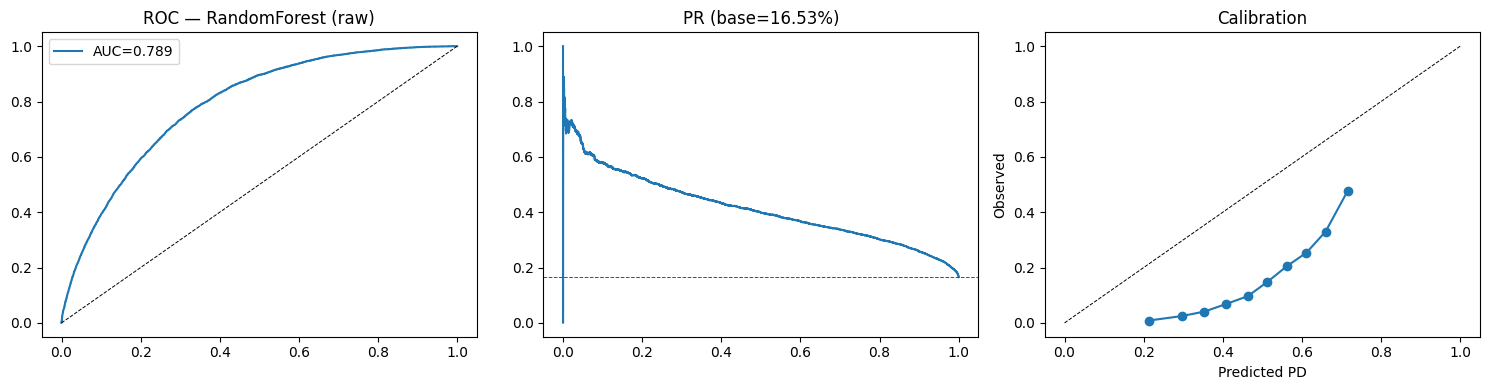

In [6]:
#  CALIBRATION / ROC / PR, BEST MODEL

best_name = board.index[0]
best_model, best_mat = fitted[best_name], models[best_name][0]
_, _, Xva, yva, Xte, yte = DATA[best_mat]

p_te = best_model.predict_proba(Xte)[:, 1]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fpr, tpr, _ = roc_curve(yte, p_te)
ax[0].plot(fpr, tpr, label=f"AUC={roc_auc_score(yte, p_te):.3f}"); ax[0].plot([0,1],[0,1],"k--",lw=.7)
ax[0].set_title("ROC — " + best_name); ax[0].legend()
pr, rc, _ = precision_recall_curve(yte, p_te)
ax[1].plot(rc, pr); ax[1].axhline(yte.mean(), color="r", ls="--", lw=.7)
ax[1].set_title(f"PR (base={yte.mean():.2%})")
frac, mean_pred = calibration_curve(yte, p_te, n_bins=10, strategy="quantile")
ax[2].plot(mean_pred, frac, "o-"); ax[2].plot([0,1],[0,1],"k--",lw=.7)
ax[2].set_title("Calibration"); ax[2].set_xlabel("Predicted PD"); ax[2].set_ylabel("Observed")
plt.tight_layout(); plt.show()


In [7]:
# ROLLING (WALK-FORWARD) CV, 2000-2005 ONLY (stops before VAL_YEAR)
# fit on years [2000, v-1], validate on year v; pool OOF predictions

def fold_plan(y0, y1, warmup=3):
    return [((y0, v - 1), v) for v in range(y0 + warmup, y1 + 1)]

folds = fold_plan(2000, VAL_YEAR - 1)   # validate 2003, 2004, 2005 (2006/2007 untouched)
print("folds:", [(f"{a}-{b} -> {v}") for (a, b), v in folds])

oof = {name: {"y": [], "p": []} for name in models}

for (a, b), v in folds:
    tr = split_by_years(og_df, a, b)
    va = split_by_years(og_df, v, v)
    A_fold = fit_fe(tr)                              # relearned per fold; no leakage
    woe_tr_f, raw_tr_f = apply_fe(tr, A_fold)
    woe_va_f, raw_va_f = apply_fe(va, A_fold)
    ytr_f = woe_tr_f["is_default"]; yva_f = woe_va_f["is_default"]

    for name, (mat, model_template) in models.items():
        Xtr_f = (woe_tr_f if mat == "woe" else raw_tr_f).drop(columns="is_default")
        Xva_f = (woe_va_f if mat == "woe" else raw_va_f).drop(columns="is_default").reindex(columns=Xtr_f.columns, fill_value=0)
        model = model_template.__class__(**model_template.get_params())
        model.fit(Xtr_f, ytr_f)
        p = model.predict_proba(Xva_f)[:, 1]
        oof[name]["y"].append(np.asarray(yva_f)); oof[name]["p"].append(np.asarray(p))
    print(f"  fold train {a}-{b} -> val {v}: {len(va):,} rows, default {yva_f.mean()*100:.2f}%")

pooled = {name: (np.concatenate(d["y"]), np.concatenate(d["p"])) for name, d in oof.items()}

print(f"\nPooled OOF validation AUC (walk-forward, 2003-{VAL_YEAR - 1}):")
for name, (y, p) in pooled.items():
    print(f"  {name:20} AUC={roc_auc_score(y, p):.4f}")


folds: ['2000-2002 -> 2003', '2000-2003 -> 2004', '2000-2004 -> 2005']
  fold train 2000-2002 -> val 2003: 50,000 rows, default 4.07%
  fold train 2000-2003 -> val 2004: 50,000 rows, default 7.11%
  fold train 2000-2004 -> val 2005: 50,000 rows, default 11.03%

Pooled OOF validation AUC (walk-forward, 2003-2005):
  LogReg (WOE)         AUC=0.7628
  RandomForest (raw)   AUC=0.7731
  XGBoost (raw)        AUC=0.7734


AUC by scoring vintage (model trained once on (2004, 2005), features never refreshed):
      LogReg (WOE)  RandomForest (raw)  XGBoost (raw)
2000        0.7596              0.7943         0.8024
2001        0.7686              0.8010         0.8143
2002        0.7811              0.8021         0.8170
2003        0.7654              0.7695         0.7781
2004        0.7593              0.7835         0.8331
2005        0.7755              0.7925         0.8317
2006        0.7760              0.7804         0.7752
2007        0.7872              0.7890         0.7681
2008        0.7920              0.7975         0.7877
2009        0.7939              0.8036         0.8062
2010        0.7805              0.7897         0.7943


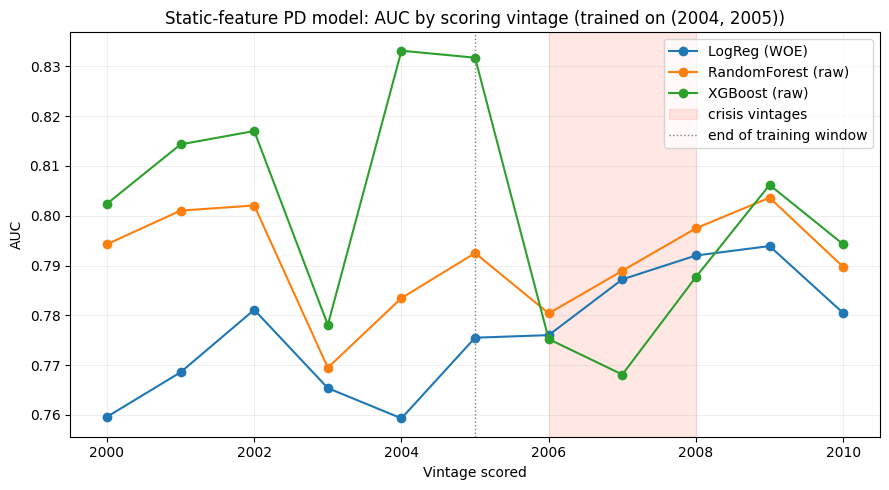

In [8]:
# PER-VINTAGE AUC, 2000-2010 (train 2004-05 once, no refit)
# same model + threshold as CELL 5/6; scored across the full vintage range

vintage_auc = {name: [] for name in models}
for name, (mat, _) in models.items():
    model = fitted[name]                          # the already-fitted model from CELL 5
    Xtr = (woe_tr if mat == "woe" else raw_tr).drop(columns="is_default")
    for yv in SCORE_YEARS:
        period = split_by_years(og_df, yv, yv)
        woe_p, raw_p = apply_fe(period, A)            
        Xp = (woe_p if mat == "woe" else raw_p).drop(columns="is_default").reindex(columns=Xtr.columns, fill_value=0)
        yp = woe_p["is_default"]
        p = model.predict_proba(Xp)[:, 1]
        auc = roc_auc_score(yp, p) if yp.nunique() > 1 else np.nan
        vintage_auc[name].append(auc)

decay = pd.DataFrame(vintage_auc, index=SCORE_YEARS)
print(f"AUC by scoring vintage (model trained once on {TRAIN_YEARS}, features never refreshed):")
print(decay.round(4).to_string())

decay.plot(marker="o", figsize=(9, 5))
plt.axvspan(2006, 2008, color="tomato", alpha=0.15, label="crisis vintages")
plt.axvline(TRAIN_YEARS[1], color="grey", ls=":", lw=1, label="end of training window")
plt.title(f"Static-feature PD model: AUC by scoring vintage (trained on {TRAIN_YEARS})")
plt.ylabel("AUC"); plt.xlabel("Vintage scored"); plt.legend(); plt.grid(alpha=0.2)
plt.tight_layout(); plt.show()